## Atividade 1: Análise de dados de uma construtora (dataset: Areas)

###### Curso: Engenharia de Produção
###### Aluno: André Cunha
###### Data: 29/03/2026
###### Orientador: Prof. Guilherme Guihermino Neto

*1. Importanto a base de dados (.xls)*

In [8]:
import pandas as pd
from google.colab import files
import io

uploaded = files.upload()
nome_arquivo = next(iter(uploaded)) # pega o nome do arquivo
dados = pd.read_excel(io.BytesIO(uploaded[nome_arquivo]))

print(dados.head(10))

Saving areas.xls to areas (7).xls
   Id Bloco  Andar  Final  Sala  Cozinha  Banheiro  Dorm  Rachadura  Infiltr
0   1     A      1      1  27.8      7.9       5.0  11.6          0        0
1   2     A      1      2  28.3      7.3       5.4  13.1          0        0
2   3     A      1      3  27.1      7.1       5.0  14.9          0        0
3   4     A      1      4  26.5      8.4       3.9  12.4          1        1
4   5     A      2      1  27.7      7.6       4.7  12.1          0        0
5   6     A      2      2  28.3      7.7       4.6  14.3          0        0
6   7     A      2      3  27.7      8.1       3.9  13.0          0        0
7   8     A      2      4  28.1      7.7       4.5  14.4          0        0
8   9     A      3      1  26.6      8.2       3.5  13.0          1        1
9  10     A      3      2  27.3      7.6       3.8  12.8          0        0
['areas (7).xls']


*2. Qual o número total de apartamentos no empreendimento?*

In [11]:
total_apartamentos = len(dados)
print(f"O número total de apartamentos no empreendimento é: {total_apartamentos}")

O número total de apartamentos no empreendimento é: 152


*3. Quantos apartamentos existem por bloco? E por andar?*

In [18]:
# Tabela com os dados combinados
apartamentos_por_bloco_e_andar = dados.groupby(['Bloco', 'Andar']).size().reset_index(name='Total Apartamentos')
print("Número de apartamentos por bloco e andar:")
print(apartamentos_por_bloco_e_andar)

# Visualização apenas por bloco:
apartamentos_por_bloco = dados.groupby('Bloco').size().reset_index(name='Total Apartamentos')
print("\nNúmero de apartamentos por bloco:")
print(apartamentos_por_bloco)

# Visualização apenas por andar:
apartamentos_por_andar = dados.groupby('Andar').size().reset_index(name='Total Apartamentos')
print("\nNúmero de apartamentos por andar (geral, sem considerar blocos):")
print(apartamentos_por_andar)

Número de apartamentos por bloco e andar:
   Bloco  Andar  Total Apartamentos
0      A      1                   4
1      A      2                   4
2      A      3                   4
3      A      4                   4
4      A      5                   4
5      A      6                   4
6      A      7                   4
7      A      8                   4
8      A      9                   4
9      A     10                   4
10     A     11                   4
11     A     12                   4
12     A     13                   4
13     A     14                   4
14     A     15                   4
15     A     16                   4
16     A     17                   4
17     A     18                   4
18     A     19                   4
19     B      1                   4
20     B      2                   4
21     B      3                   4
22     B      4                   4
23     B      5                   4
24     B      6                   4
25     B      7       

*4. Calcule a área útil total para cada apartamento. Armazene esta informação em uma variável denominada Total.*



In [ ]:
# Calcula a área útil total de cada apartamento somando as áreas de Sala, Cozinha, Banheiro e Dormitório.
# O resultado é armazenado em uma nova coluna chamada 'Area_total' no DataFrame 'dados'.
dados['Area_total'] = dados['Sala'] + dados['Cozinha'] + dados['Banheiro'] + dados['Dorm']

# Exibe as primeiras 5 linhas do DataFrame 'dados' para verificar a nova coluna 'Area_total' e seus valores.
print("DataFrame com a nova coluna 'Area_total' de área útil:")
print(dados.head())

*5. Calcule medidas descritivas para as áreas de cada cômodo, e a área total, separadas por bloco.*

In [24]:
# Define as colunas para as quais as medidas descritivas serão calculadas.
colunas_areas = ['Sala', 'Cozinha', 'Banheiro', 'Dorm', 'Area_total']

# Itera sobre cada coluna e calcula e exibe as medidas descritivas separadamente.
for coluna in colunas_areas:
    print(f"\nMedidas descritivas para {coluna} por bloco:")
    descritivas_por_bloco_comodo = dados.groupby('Bloco')[coluna].describe()
    print(descritivas_por_bloco_comodo)



Medidas descritivas para Sala por bloco:
       count       mean       std   min   25%    50%     75%   max
Bloco                                                             
A       76.0  28.093421  1.082631  25.6  27.5  27.95  28.900  30.9
B       76.0  23.131579  0.848875  20.9  22.5  23.10  23.725  25.0

Medidas descritivas para Cozinha por bloco:
       count      mean       std  min  25%  50%    75%  max
Bloco                                                      
A       76.0  7.928947  0.465279  6.5  7.7  8.0  8.200  9.2
B       76.0  7.881579  0.604805  6.4  7.5  7.8  8.325  9.6

Medidas descritivas para Banheiro por bloco:
       count      mean       std  min  25%  50%  75%  max
Bloco                                                    
A       76.0  4.450000  0.462313  3.5  4.1  4.5  4.7  5.4
B       76.0  4.464474  0.515805  2.9  4.1  4.5  4.8  5.8

Medidas descritivas para Dorm por bloco:
       count       mean       std   min   25%   50%     75%   max
Bloco              

*6.Faça gráficos para as áreas de cada cômodo e a área total, separadas por bloco (podem ser
boxplots).*

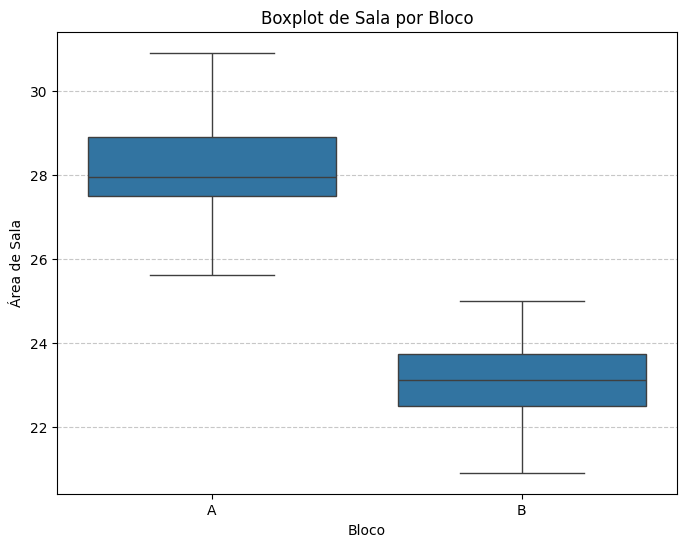

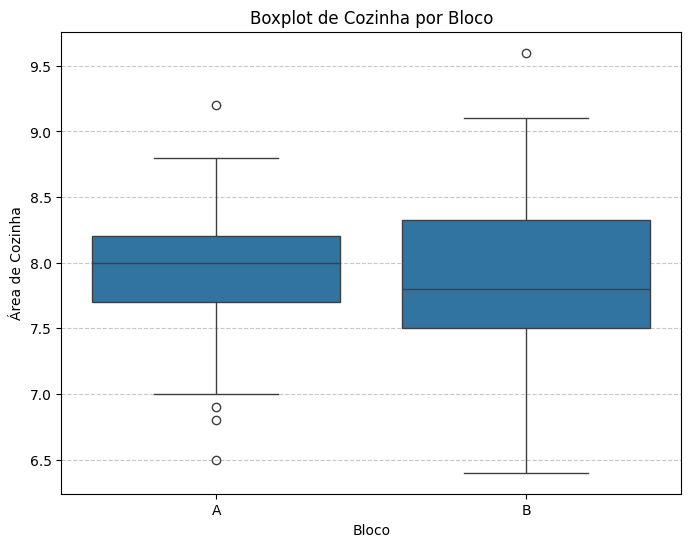

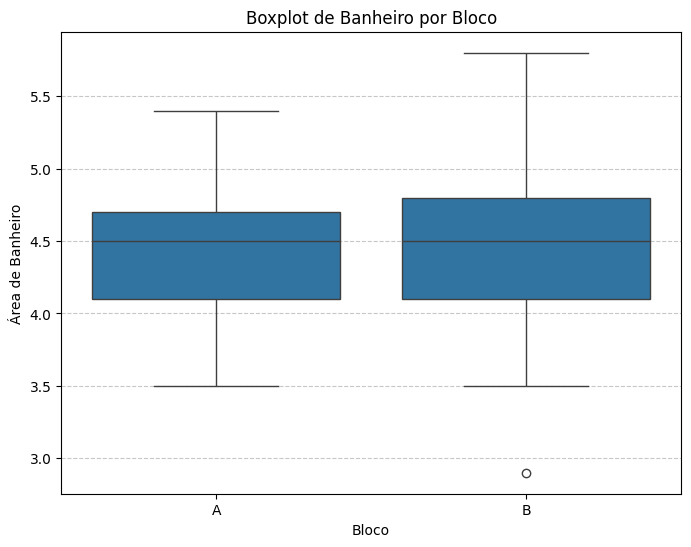

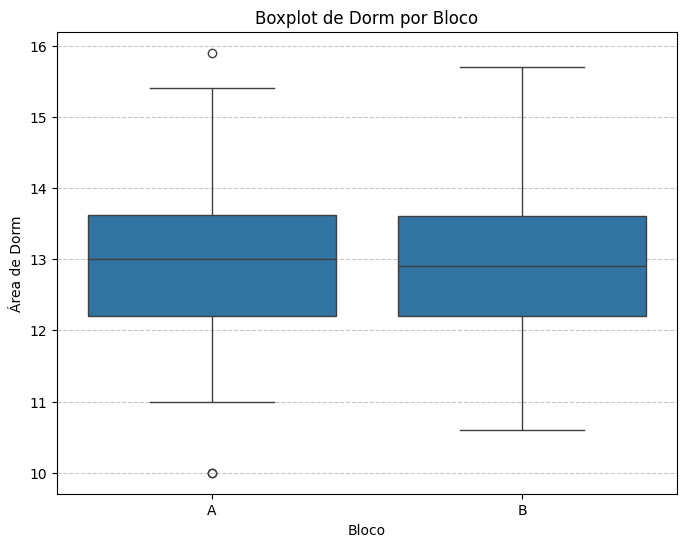

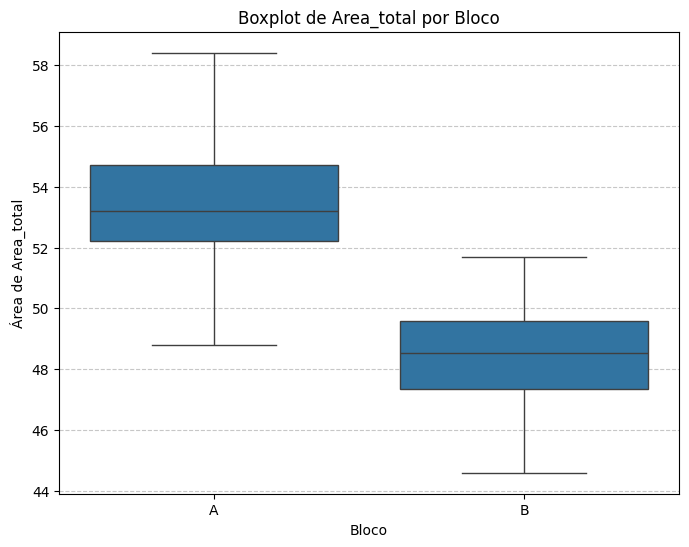

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

colunas_areas = ['Sala', 'Cozinha', 'Banheiro', 'Dorm', 'Area_total']

for coluna in colunas_areas:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Bloco', y=coluna, data=dados)
    plt.title(f'Boxplot de {coluna} por Bloco')
    plt.xlabel('Bloco')
    plt.ylabel(f'Área de {coluna}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


*7. Baseando-se nos itens anteriores, você diria que existem diferenças nas áreas dos
apartamentos dos blocos A e B? Em caso positivo, qual (is) cômodo (s) apresenta (m) o problema?*

> Sim, e a identificação dessa disparidade de áreas entre os comôdos dos blocos A e B foi determinada pela variável "Sala", a qual apresentou um valor maior de média e máximo no bloco A, quando comparado com o mesmo comôdo do bloco oposto.  

> Portanto, identificada essa diferença,  é possível justificar o maior valor médio e máximo também para a variável "Area_total".

> Por fim, nos demais cômodos (Cozinha, Banheiro e Dormitório), as medidas estão muito similares entre os dois blocos.

* Abaixo temos a demonstração gráfica da resposta comentada acima:

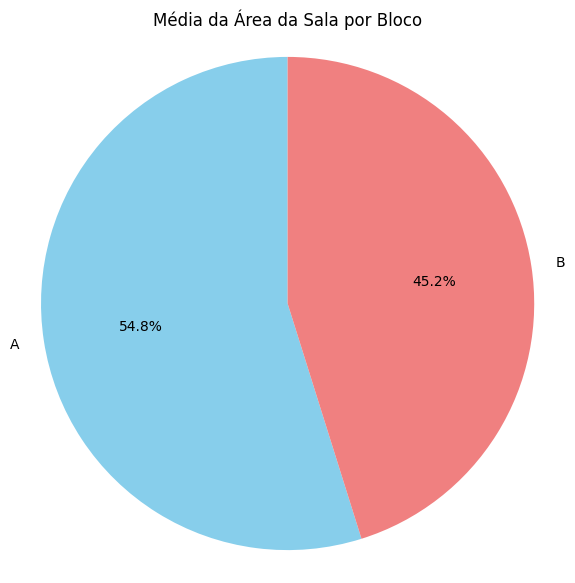

In [29]:
import matplotlib.pyplot as plt

# Armazena a média da área da 'Sala' por 'Bloco'
media_sala_por_bloco = dados.groupby('Bloco')['Sala'].mean()

# Cria o gráfico de pizza
plt.figure(figsize=(7, 7))
plt.pie(
    media_sala_por_bloco,
    labels=media_sala_por_bloco.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['skyblue', 'lightcoral']
)
plt.title('Média da Área da Sala por Bloco')
plt.axis('equal') # Garante que o círculo seja desenhado corretamente
plt.show()

*8. Com a informação contida na variável Andar, divida os apartamentos em três categorias: baixo, médio e alto (crie uma nova coluna para armazenar esta nova variável).*

In [26]:
#  Estabelecemos os limites para as categorias de  cada andar:
# Andares de 1 a 6: Baixo
# Andares de 7 a 13: Médio
# Andares de 14 a 19: Alto
bins = [0, 6, 13, 19]
labels = ['Baixo', 'Médio', 'Alto']

# Cria a nova coluna 'Categoria_Andar' usando pd.cut
dados['Categoria_Andar'] = pd.cut(dados['Andar'], bins=bins, labels=labels, right=True)

# Exibe as primeiras linhas do DataFrame com a nova coluna para verificação
print("DataFrame com a nova coluna 'Categoria_Andar':")
print(dados[['Andar', 'Categoria_Andar']].head(10))
print("\nContagem de apartamentos por categoria de andar:")
print(dados['Categoria_Andar'].value_counts())


DataFrame com a nova coluna 'Categoria_Andar':
   Andar Categoria_Andar
0      1           Baixo
1      1           Baixo
2      1           Baixo
3      1           Baixo
4      2           Baixo
5      2           Baixo
6      2           Baixo
7      2           Baixo
8      3           Baixo
9      3           Baixo

Contagem de apartamentos por categoria de andar:
Categoria_Andar
Médio    56
Baixo    48
Alto     48
Name: count, dtype: int64


*9. Estude a ocorrência de rachaduras e infiltrações para cada categoria de andar. Existe algum nível em que há mais rachaduras ou infiltrações?*

In [27]:
# Agrupa os dados por 'Categoria_Andar' e calcula a soma de rachaduras e infiltrações
rachaduras_infiltracoes_por_andar = dados.groupby('Categoria_Andar')[['Rachadura', 'Infiltr']].sum()

print("Ocorrência de Rachaduras e Infiltrações por Categoria de Andar:")
print(rachaduras_infiltracoes_por_andar)

print("\nAnálise:")
# Identifica a categoria de andar com mais rachaduras
mais_rachaduras = rachaduras_infiltracoes_por_andar['Rachadura'].idxmax()
num_mais_rachaduras = rachaduras_infiltracoes_por_andar['Rachadura'].max()
print(f"A categoria de andar com o maior número de rachaduras é '{mais_rachaduras}' com {num_mais_rachaduras} ocorrências.")

# Identifica a categoria de andar com mais infiltrações
mais_infiltracoes = rachaduras_infiltracoes_por_andar['Infiltr'].idxmax()
num_mais_infiltracoes = rachaduras_infiltracoes_por_andar['Infiltr'].max()
print(f"A categoria de andar com o maior número de infiltrações é '{mais_infiltracoes}' com {num_mais_infiltracoes} ocorrências.")

# Podemos também considerar as proporções, caso o número de apartamentos por categoria seja diferente
contagem_por_categoria = dados['Categoria_Andar'].value_counts().sort_index()
print("\nContagem de apartamentos por categoria de andar:")
print(contagem_por_categoria)

proporcao_rachaduras = (rachaduras_infiltracoes_por_andar['Rachadura'] / contagem_por_categoria).round(2)
proporcao_infiltracoes = (rachaduras_infiltracoes_por_andar['Infiltr'] / contagem_por_categoria).round(2)

print("\nProporção de apartamentos com Rachaduras por Categoria de Andar:")
print(proporcao_rachaduras)

print("\nProporção de apartamentos com Infiltrações por Categoria de Andar:")
print(proporcao_infiltracoes)


Ocorrência de Rachaduras e Infiltrações por Categoria de Andar:
                 Rachadura  Infiltr
Categoria_Andar                    
Baixo                   12        7
Médio                   41        9
Alto                    14       28

Análise:
A categoria de andar com o maior número de rachaduras é 'Médio' com 41 ocorrências.
A categoria de andar com o maior número de infiltrações é 'Alto' com 28 ocorrências.

Contagem de apartamentos por categoria de andar:
Categoria_Andar
Baixo    48
Médio    56
Alto     48
Name: count, dtype: int64

Proporção de apartamentos com Rachaduras por Categoria de Andar:
Categoria_Andar
Baixo    0.25
Médio    0.73
Alto     0.29
dtype: float64

Proporção de apartamentos com Infiltrações por Categoria de Andar:
Categoria_Andar
Baixo    0.15
Médio    0.16
Alto     0.58
dtype: float64


/tmp/ipykernel_3631/456083018.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rachaduras_infiltracoes_por_andar = dados.groupby('Categoria_Andar')[['Rachadura', 'Infiltr']].sum()
